In [2]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.captureWarnings(True)

# Now your regular imports
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error
from mlxtend.frequent_patterns import fpgrowth, association_rules

uploaded = files.upload()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [3]:
import io

# Assuming 'uploaded' is available from files.upload() in a previous cell
# and contains the uploaded file content.
# We can get the filename from the keys of the 'uploaded' dictionary.
if 'uploaded' in locals() and uploaded:
    fn = list(uploaded.keys())[0] # Get the first (and likely only) filename
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
else:
    print("Error: No file was uploaded or 'uploaded' variable is not available.")
    print("Please ensure 'files.upload()' was successfully executed and a file was selected.")
    # Exit or handle the error appropriately if df cannot be created
    raise FileNotFoundError("No uploaded file found to create DataFrame 'df'")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (1000, 9)
Columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 5 rows:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


# Data Preprocessing

In [4]:
df_processed = df.copy()

# Handle missing values
if df_processed.isnull().sum().sum() > 0:
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# Data cleaning
df_processed.drop_duplicates(inplace=True)
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if (df_processed[col] < 0).any():
        df_processed[col] = df_processed[col].abs()
if 'Date' in df_processed.columns:
    df_processed['Date'] = pd.to_datetime(df_processed['Date'])

# Data discretization
if 'Age' in df_processed.columns:
    df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                        bins=[0, 25, 35, 50, 100],
                                        labels=['Young', 'Young Adult', 'Middle Age', 'Senior'])
if 'Total Amount' in df_processed.columns:
    df_processed['Spending_Category'] = pd.qcut(df_processed['Total Amount'],
                                                 q=3,
                                                 labels=['Low', 'Medium', 'High'])
if 'Price per Unit' in df_processed.columns:
    df_processed['Price_Level'] = pd.cut(df_processed['Price per Unit'],
                                          bins=[0, 50, 200, 1000],
                                          labels=['Budget', 'Standard', 'Premium'])

# Encode categorical variables
categorical_cols = df_processed.select_dtypes(include=['object']).columns
encoders = {}
for col in categorical_cols:
    if col not in ['Transaction ID', 'Customer ID', 'Date']:
        le = LabelEncoder()
        df_processed[f'{col}_Encoded'] = le.fit_transform(df_processed[col].astype(str))
        encoders[col] = le

# Normalize numerical features
numerical_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()
skip_cols = [col for col in df_processed.columns if 'Encoded' in col or 'ID' in col or 'Transaction' in col]
numerical_features = [col for col in numerical_features if col not in skip_cols]

original_values = {}
if len(numerical_features) > 0:
    for col in numerical_features:
        original_values[col] = df_processed[col].copy()
    scaler = MinMaxScaler()
    df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

# Clustering Analysis (Unsupervised Learning)

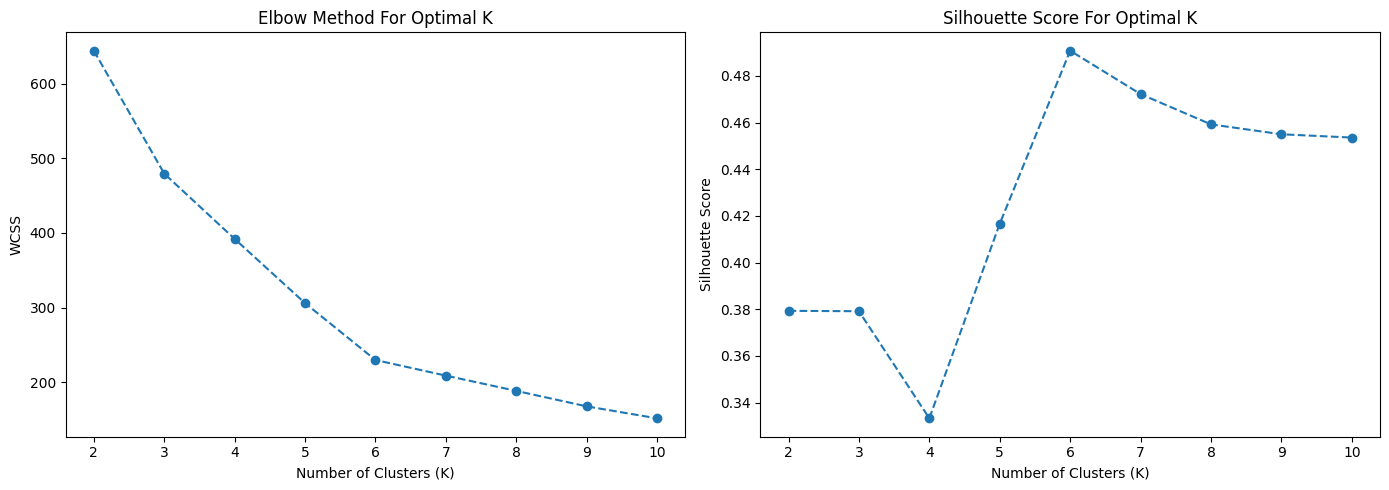


Optimal number of clusters (based on highest silhouette score): 6

Cluster Analysis for 6 Clusters:
              Age  Quantity  Price per Unit  Total Amount  Gender  \
Cluster                                                             
0        0.494596  0.519774        0.304074      0.199900    Male   
1        0.547101  0.511494        0.324682      0.223847  Female   
2        0.542973  0.461240        0.336965      0.223344    Male   
3        0.485987  0.506024        0.331262      0.215586  Female   
4        0.488747  0.527451        0.323591      0.215890  Female   
5        0.486741  0.501182        0.339082      0.233989    Male   

        Product Category  
Cluster                   
0               Clothing  
1               Clothing  
2            Electronics  
3                 Beauty  
4            Electronics  
5                 Beauty  


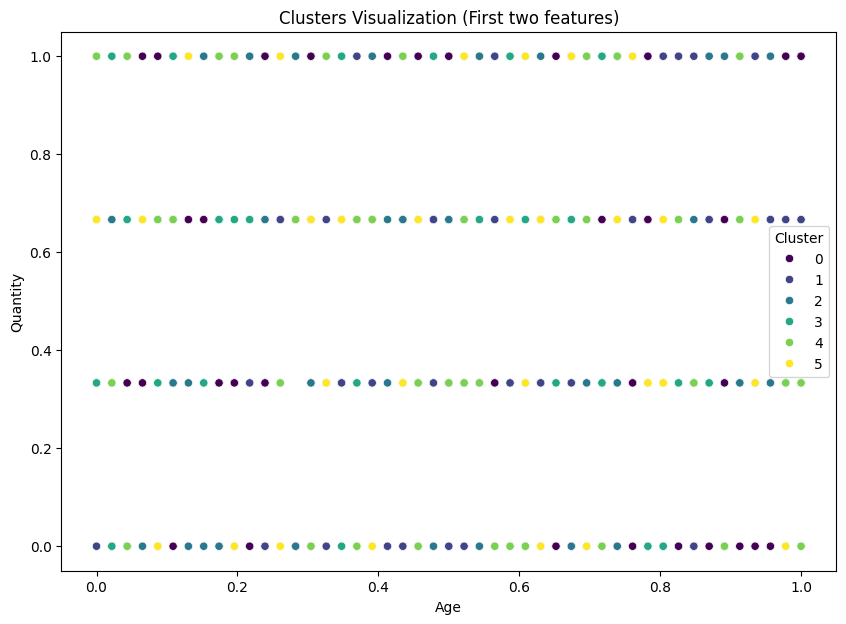

In [5]:
# Prepare data for clustering
cluster_features = [col for col in numerical_features if col not in ['Total Amount', 'Price per Unit']]
cluster_features.extend([col for col in df_processed.columns if 'Encoded' in col and 'Spending' not in col and 'Price_Level' not in col])
cluster_df = df_processed[cluster_features].dropna()

if cluster_df.empty:
    print("No suitable features for clustering after filtering. Skipping clustering analysis.")
else:
    # Determine optimal number of clusters (Elbow Method and Silhouette Score)
    wcss = []  # Within-cluster sum of squares
    silhouette_scores = []
    max_clusters = min(10, len(cluster_df) - 1) # Ensure max_clusters is less than number of samples

    if max_clusters < 2:
        print("Not enough data points to perform meaningful clustering (need at least 2). Skipping clustering analysis.")
    else:
        for i in range(2, max_clusters + 1):
            kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
            kmeans.fit(cluster_df)
            wcss.append(kmeans.inertia_)
            score = silhouette_score(cluster_df, kmeans.labels_)
            silhouette_scores.append(score)

        # Plotting the Elbow Method
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.plot(range(2, max_clusters + 1), wcss, marker='o', linestyle='--')
        plt.title('Elbow Method For Optimal K')
        plt.xlabel('Number of Clusters (K)')
        plt.ylabel('WCSS')

        # Plotting the Silhouette Scores
        plt.subplot(1, 2, 2)
        plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o', linestyle='--')
        plt.title('Silhouette Score For Optimal K')
        plt.xlabel('Number of Clusters (K)')
        plt.ylabel('Silhouette Score')
        plt.tight_layout()
        plt.show()

        # Choose optimal K based on analysis (e.g., highest silhouette score)
        optimal_k = 2 # Default value if no scores are available
        if silhouette_scores:
            optimal_k = range(2, max_clusters + 1)[np.argmax(silhouette_scores)]
        print(f"\nOptimal number of clusters (based on highest silhouette score): {optimal_k}")

        # Apply K-Means clustering with optimal K
        kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
        clusters = kmeans.fit_predict(cluster_df)
        df_processed['Cluster'] = clusters

        # Analyze cluster characteristics
        print(f"\nCluster Analysis for {optimal_k} Clusters:")
        cluster_summary = df_processed.groupby('Cluster')[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mean()
        cluster_summary_categorical = df_processed.groupby('Cluster')[['Gender_Encoded', 'Product Category_Encoded']].agg(lambda x: x.mode()[0]) # mode for categorical

        # Inverse transform encoded categorical features for better interpretation
        for col_name, encoder in encoders.items():
            if f'{col_name}_Encoded' in cluster_summary_categorical.columns:
                # Map encoded numerical mode back to original labels
                cluster_summary_categorical[col_name] = cluster_summary_categorical[f'{col_name}_Encoded'].apply(lambda x: encoder.inverse_transform([int(x)])[0])
                cluster_summary_categorical = cluster_summary_categorical.drop(columns=[f'{col_name}_Encoded'])

        print(pd.concat([cluster_summary, cluster_summary_categorical], axis=1))

        # Visualization of clusters (example using first two components)
        if len(cluster_features) >= 2:
            plt.figure(figsize=(10, 7))
            sns.scatterplot(x=cluster_df.iloc[:, 0], y=cluster_df.iloc[:, 1], hue=df_processed['Cluster'], palette='viridis', legend='full')
            plt.title('Clusters Visualization (First two features)')
            plt.xlabel(cluster_features[0])
            plt.ylabel(cluster_features[1])
            plt.show()
        else:
            print("Not enough features to create a 2D scatter plot for cluster visualization.")

# Classification Analysis (Supervised Learning)

Naïve Bayes Accuracy: 0.9100

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        90
         Low       0.80      1.00      0.89       105
      Medium       1.00      0.74      0.85       105

    accuracy                           0.91       300
   macro avg       0.93      0.91      0.91       300
weighted avg       0.93      0.91      0.91       300



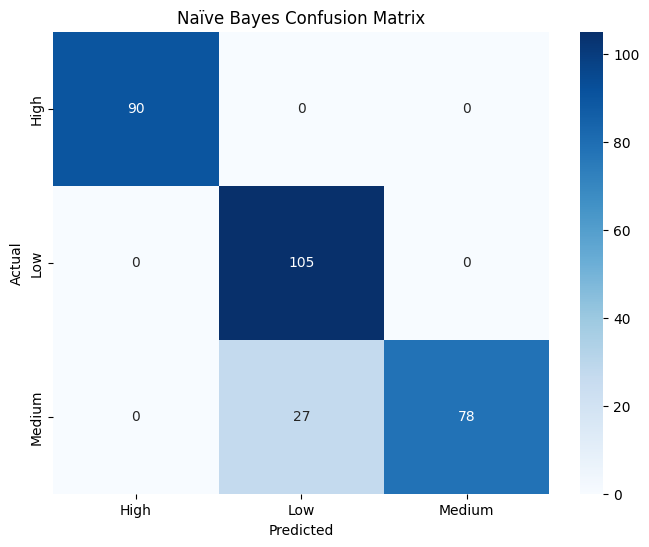

Decision Tree Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        90
         Low       1.00      1.00      1.00       105
      Medium       1.00      1.00      1.00       105

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



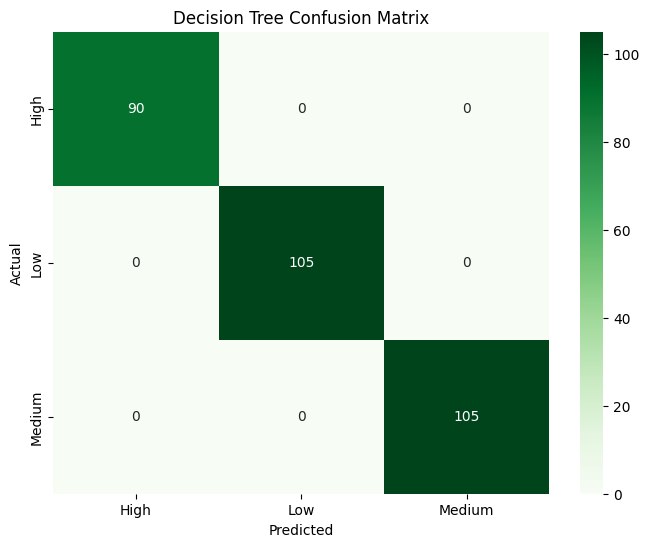


Feature Importance:
                    feature  importance
3              Total Amount         1.0
0                       Age         0.0
1                  Quantity         0.0
2            Price per Unit         0.0
4            Gender_Encoded         0.0
5  Product Category_Encoded         0.0

Model Comparison:
Naïve Bayes Accuracy: 0.9100
Decision Tree Accuracy: 1.0000

Best Model: Decision Tree
Naïve Bayes CV: 0.9070 (+/- 0.0338)
Decision Tree CV: 1.0000 (+/- 0.0000)


In [6]:
# Prepare target
if 'Spending_Category' in df_processed.columns:
    target_col = 'Spending_Category_Encoded'
    if target_col not in df_processed.columns:
        le_target = LabelEncoder()
        df_processed[target_col] = le_target.fit_transform(df_processed['Spending_Category'])
        target_labels = le_target.classes_
else:
    if 'Total Amount' in df_processed.columns:
        original_amount = original_values.get('Total Amount', df['Total Amount'])
        median_amount = np.median(original_amount)
        df_processed['Spending_Level'] = pd.cut(original_amount,
                                                bins=[0, median_amount, float('inf')],
                                                labels=['Low', 'High'])
        le_target = LabelEncoder()
        df_processed['Spending_Level_Encoded'] = le_target.fit_transform(df_processed['Spending_Level'])
        target_col = 'Spending_Level_Encoded'
        target_labels = le_target.classes_

# Select features
feature_cols = []
for col in numerical_features[:4]:
    if col in df_processed.columns:
        feature_cols.append(col)
encoded_cols = [col for col in df_processed.columns if 'Encoded' in col and col != target_col]
feature_cols.extend(encoded_cols[:4])
feature_cols = list(dict.fromkeys(feature_cols))

X = df_processed[feature_cols].fillna(0)
y = df_processed[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Naïve Bayes
b_model = GaussianNB()
b_model.fit(X_train, y_train)
nb_pred = b_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naïve Bayes Accuracy: {nb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=target_labels, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels, yticklabels=target_labels)
plt.title('Naïve Bayes Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Decision Tree
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=target_labels, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=target_labels, yticklabels=target_labels)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

# Model Comparison
print(f"\nModel Comparison:")
print(f"Naïve Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

best_model = "Decision Tree" if dt_accuracy >= nb_accuracy else "Naïve Bayes"
print(f"\nBest Model: {best_model}")

# Cross-validation
try:
    nb_cv = cross_val_score(b_model, X, y, cv=min(5, len(X)//10), scoring='accuracy')
    dt_cv = cross_val_score(dt_model, X, y, cv=min(5, len(X)//10), scoring='accuracy')
    print(f"Naïve Bayes CV: {nb_cv.mean():.4f} (+/- {nb_cv.std()*2:.4f})")
    print(f"Decision Tree CV: {dt_cv.mean():.4f} (+/- {dt_cv.std()*2:.4f})")
except:
    pass

# Association Mining


In [7]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Association Mining

# Prepare data for association analysis
# Create a list of products bought in each transaction
# Group by Transaction ID and collect all Product Categories for each transaction
transaction_products = df_processed.groupby('Transaction ID')['Product Category'].apply(list).reset_index()

# One-hot encode the product categories for fpgrowth algorithm
# First, create a list of all unique products
all_products = df_processed['Product Category'].unique()

# Create an empty dataframe with Transaction ID as index and products as columns
data_for_fpgrowth = pd.DataFrame(index=transaction_products['Transaction ID'], columns=all_products).fillna(False)

# Populate the dataframe: mark True if a product is in the transaction
for index, row in transaction_products.iterrows():
    transaction_id = row['Transaction ID']
    products_in_transaction = row['Product Category']
    for product in products_in_transaction:
        data_for_fpgrowth.loc[transaction_id, product] = True

# Run the FPGrowth algorithm to find frequent itemsets
frequent_itemsets_fp = fpgrowth(data_for_fpgrowth, min_support=0.01, use_colnames=True)

# Generate association rules
rules_fp = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1)

# Display the top rules by lift
print("\nTop 10 Association Rules (FPGrowth, sorted by Lift):")
print(rules_fp.sort_values(['lift'], ascending=False).head(10))

# Interpretation of rules
print("\nInterpretation of Association Rules (FPGrowth):")
if not rules_fp.empty:
    top_rule_fp = rules_fp.sort_values(['lift'], ascending=False).iloc[0]
    antecedents_str_fp = ', '.join(list(top_rule_fp['antecedents']))
    consequents_str_fp = ', '.join(list(top_rule_fp['consequents']))
    print(f"  • Customers who buy {antecedents_str_fp} are {top_rule_fp['lift']:.2f} times more likely to buy {consequents_str_fp}.")
    print(f"    This rule has a confidence of {top_rule_fp['confidence']:.2f}, meaning {top_rule_fp['confidence'] * 100:.0f}% of transactions with {antecedents_str_fp} also contain {consequents_str_fp}.")
    print(f"    Its support is {top_rule_fp['support']:.2f}, indicating it appears in {top_rule_fp['support'] * 100:.0f}% of all transactions.")
else:
    print("No significant association rules found based on the given support and lift thresholds (FPGrowth).")


Top 10 Association Rules (FPGrowth, sorted by Lift):
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []

Interpretation of Association Rules (FPGrowth):
No significant association rules found based on the given support and lift thresholds (FPGrowth).


# Regression Analysis



Regression Equation:
Total Amount = -175.00 - 56.63 × Age + 554.19 × Quantity + 1178.67 × Price per Unit + 2.29 × Gender_Encoded + 0.05 × Product Category_Encoded

R-squared: 0.8547
RMSE: 201.53

Interpretation: 85.5% of variance in Total Amount is explained by the model

Feature Impact:
                    feature  coefficient     abs_coef
2            Price per Unit  1178.674292  1178.674292
1                  Quantity   554.185308   554.185308
0                       Age   -56.633069    56.633069
3            Gender_Encoded     2.294874     2.294874
4  Product Category_Encoded     0.050615     0.050615

Business Implications:
  • Increasing Price per Unit by 1 unit increases spending by $1178.67


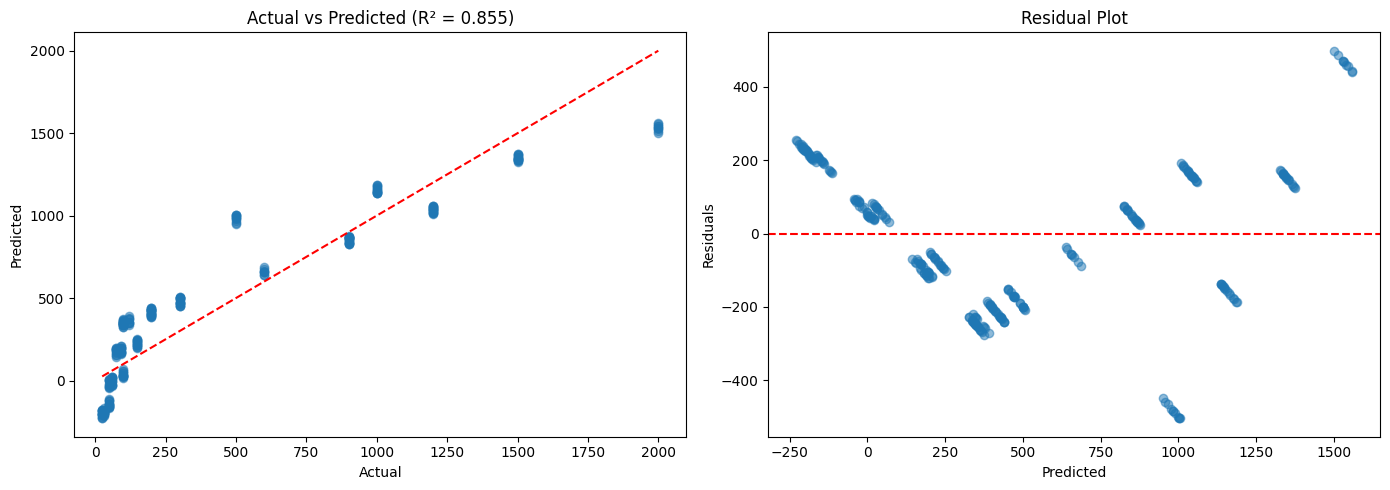

In [8]:
if 'Total Amount' in df.columns and len(numerical_features) > 1:
    y_reg = original_values.get('Total Amount', df['Total Amount']).values
    X_reg_cols = [col for col in numerical_features if col != 'Total Amount']

    encoded_for_reg = [col for col in df_processed.columns if 'Encoded' in col and 'Spending' not in col][:2]

    if len(encoded_for_reg) > 0:
        X_reg = np.column_stack([df_processed[col].values for col in X_reg_cols] +
                                [df_processed[col].values for col in encoded_for_reg])
        all_features = X_reg_cols + encoded_for_reg
    else:
        X_reg = df_processed[X_reg_cols].values
        all_features = X_reg_cols

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

    lr_model = LinearRegression()
    lr_model.fit(X_train_r, y_train_r)
    y_pred = lr_model.predict(X_test_r)

    r2 = r2_score(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))

    print(f"\nRegression Equation:")
    equation = f"Total Amount = {lr_model.intercept_:.2f}"
    for i, feature in enumerate(all_features):
        sign = "+" if lr_model.coef_[i] >= 0 else "-"
        equation += f" {sign} {abs(lr_model.coef_[i]):.2f} × {feature}"
    print(equation)

    print(f"\nR-squared: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")

    print(f"\nInterpretation: {r2*100:.1f}% of variance in Total Amount is explained by the model")

    # Feature impact
    coef_df = pd.DataFrame({
        'feature': all_features,
        'coefficient': lr_model.coef_,
        'abs_coef': np.abs(lr_model.coef_)
    }).sort_values('abs_coef', ascending=False)
    print("\nFeature Impact:")
    print(coef_df)

    # Business implications
    print("\nBusiness Implications:")
    pos_factors = coef_df[coef_df['coefficient'] > 0]
    if len(pos_factors) > 0:
        top_pos = pos_factors.iloc[0]
        print(f"  • Increasing {top_pos['feature']} by 1 unit increases spending by ${top_pos['coefficient']:.2f}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test_r, y_pred, alpha=0.5)
    axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')

    residuals = y_test_r - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot')
    plt.tight_layout()
    plt.show()

# Model Validation and Testing

In [9]:
# Model Validation + Testing Summary

print("\n--- Model Validation and Testing Summary ---")

# Classification Model Performance (from previous analysis)
if 'nb_accuracy' in locals() and 'dt_accuracy' in locals():
    print("\nClassification Models:")
    print(f"  Naïve Bayes Accuracy: {nb_accuracy:.4f}")
    print(f"  Decision Tree Accuracy: {dt_accuracy:.4f}")
    best_class_model = "Decision Tree" if dt_accuracy >= nb_accuracy else "Naïve Bayes"
    print(f"  Conclusion: The {best_class_model} model performed better for classification.")
else:
    print("\nClassification model accuracies not found. Please run the Classification Analysis section first.")

# Regression Model Performance (from previous analysis)
if 'r2' in locals() and 'rmse' in locals():
    print("\nRegression Model (Linear Regression):")
    print(f"  R-squared: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  Conclusion: The Linear Regression model explains {r2*100:.1f}% of the variance in Total Amount.")
else:
    print("\nRegression model metrics not found. Please run the Regression Analysis section first.")

print("\nFor detailed reports, confusion matrices, and feature importance, please refer to the 'Classification Analysis' and 'Regression Analysis' sections above.")


--- Model Validation and Testing Summary ---

Classification Models:
  Naïve Bayes Accuracy: 0.9100
  Decision Tree Accuracy: 1.0000
  Conclusion: The Decision Tree model performed better for classification.

Regression Model (Linear Regression):
  R-squared: 0.8547
  RMSE: 201.53
  Conclusion: The Linear Regression model explains 85.5% of the variance in Total Amount.

For detailed reports, confusion matrices, and feature importance, please refer to the 'Classification Analysis' and 'Regression Analysis' sections above.
